<a href="https://colab.research.google.com/github/ekuelkpodar/Complex-Systems-Google-Colab-Experiment/blob/main/Global_Critical_Infrastructure_Digital_Twin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Critical Infrastructure Digital Twin
Modeling dependencies across all 16 U.S. critical infrastructure sectors.

In [1]:
!pip install networkx geopandas xgboost torch torch_geometric neo4j

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 12.8 MB/s eta 0:00:00


In [2]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define the 16 critical sectors
SECTORS = [
    'Chemical', 'Commercial Facilities', 'Communications', 'Critical Manufacturing',
    'Dams', 'Defense Industrial Base', 'Emergency Services', 'Energy',
    'Financial Services', 'Food and Agriculture', 'Government Facilities',
    'Healthcare and Public Health', 'Information Technology', 'Nuclear Reactors',
    'Transportation Systems', 'Water and Wastewater Systems'
]

# Initialize the Digital Twin Global Graph
G = nx.DiGraph()

# Add sector nodes
for sector in SECTORS:
    G.add_node(sector, type='sector', resilience_score=1.0)

print(f"Initialized Digital Twin with {G.number_of_nodes()} sectors.")

Initialized Digital Twin with 16 sectors.


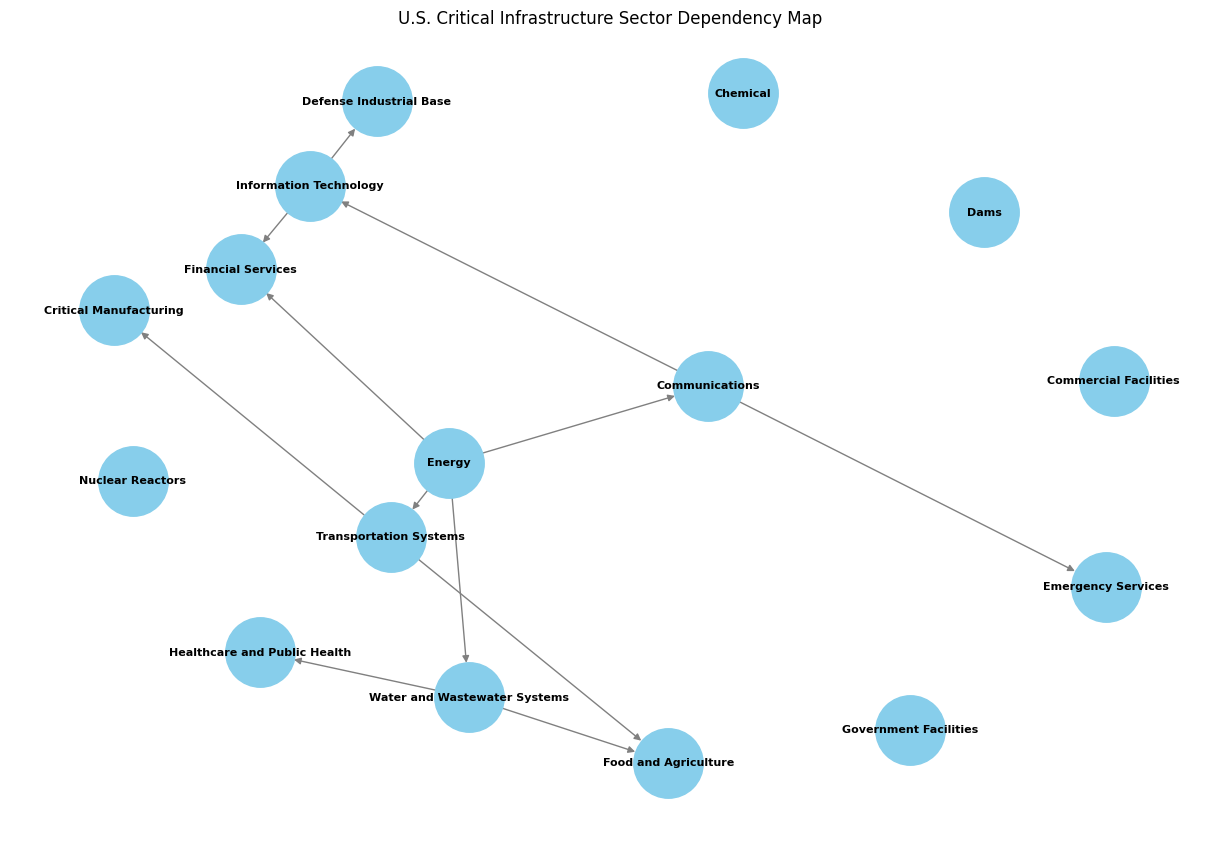

Modeled 12 key inter-sector dependencies.


In [5]:
# Define primary inter-sector dependencies
dependencies = [
    ('Energy', 'Communications'),
    ('Energy', 'Water and Wastewater Systems'),
    ('Energy', 'Transportation Systems'),
    ('Energy', 'Financial Services'),
    ('Communications', 'Information Technology'),
    ('Communications', 'Emergency Services'),
    ('Information Technology', 'Financial Services'),
    ('Information Technology', 'Defense Industrial Base'),
    ('Water and Wastewater Systems', 'Healthcare and Public Health'),
    ('Water and Wastewater Systems', 'Food and Agriculture'),
    ('Transportation Systems', 'Critical Manufacturing'),
    ('Transportation Systems', 'Food and Agriculture')
]

# Add edges to the graph
G.add_edges_from(dependencies)

# Visualize the dependency network
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='skyblue',
        node_size=2500, font_size=8, font_weight='bold',
        arrows=True, edge_color='gray')
plt.title("U.S. Critical Infrastructure Sector Dependency Map")
plt.show()

print(f"Modeled {G.number_of_edges()} key inter-sector dependencies.")

In [7]:
import torch
from torch_geometric.data import Data
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

def calculate_resilience_scores(graph):
    """Calculates resilience scores based on centralities."""
    centrality = nx.degree_centrality(graph)
    resilience = {node: 1.0 - score for node, score in centrality.items()}
    return resilience

# Update graph nodes with resilience scores
resilience_map = calculate_resilience_scores(G)
nx.set_node_attributes(G, resilience_map, "resilience_score")

# Prepare data for Graph Neural Network
node_to_idx = {node: i for i, node in enumerate(G.nodes())}
edge_index = torch.tensor([[node_to_idx[u], node_to_idx[v]] for u, v in G.edges()], dtype=torch.long).t().contiguous()

# Features: [Resilience Score]
x = torch.tensor([[G.nodes[node]["resilience_score"]] for node in G.nodes()], dtype=torch.float)
data = Data(x=x, edge_index=edge_index)

class RiskGNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(1, 16)
        self.conv2 = GCNConv(16, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return torch.sigmoid(x)

model = RiskGNN()
model.eval()
with torch.no_grad():
    risk_predictions = model(data).numpy().flatten()

print("--- GNN Risk Predictions per Sector ---")
for i, sector in enumerate(G.nodes()):
    print(f"Sector: {sector:30} | Risk Score: {risk_predictions[i]:.4f}")

--- GNN Risk Predictions per Sector ---
Sector: Chemical                       | Risk Score: 0.5541
Sector: Commercial Facilities          | Risk Score: 0.5541
Sector: Communications                 | Risk Score: 0.5529
Sector: Critical Manufacturing         | Risk Score: 0.5483
Sector: Dams                           | Risk Score: 0.5541
Sector: Defense Industrial Base        | Risk Score: 0.5452
Sector: Emergency Services             | Risk Score: 0.5483
Sector: Energy                         | Risk Score: 0.5398
Sector: Financial Services             | Risk Score: 0.5593
Sector: Food and Agriculture           | Risk Score: 0.5576
Sector: Government Facilities          | Risk Score: 0.5541
Sector: Healthcare and Public Health   | Risk Score: 0.5483
Sector: Information Technology         | Risk Score: 0.5465
Sector: Nuclear Reactors               | Risk Score: 0.5541
Sector: Transportation Systems         | Risk Score: 0.5529
Sector: Water and Wastewater Systems   | Risk Score: 0.5529


In [8]:
import torch.optim as optim

# Initialize model, optimizer, and loss function
model = RiskGNN()
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.MSELoss()

# For demonstration, we'll use the resilience scores as a proxy for 'ground truth' risk targets
# In a real scenario, these would be historical failure rates
targets = 1.0 - x

# Simple training loop
model.train()
for epoch in range(200):
    optimizer.zero_grad()
    out = model(data)
    loss = criterion(out, targets)
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(f'Epoch {epoch}: Loss {loss.item():.4f}')

print("Training complete.")

Epoch 0: Loss 0.1446
Epoch 50: Loss 0.0079
Epoch 100: Loss 0.0077
Epoch 150: Loss 0.0076
Training complete.


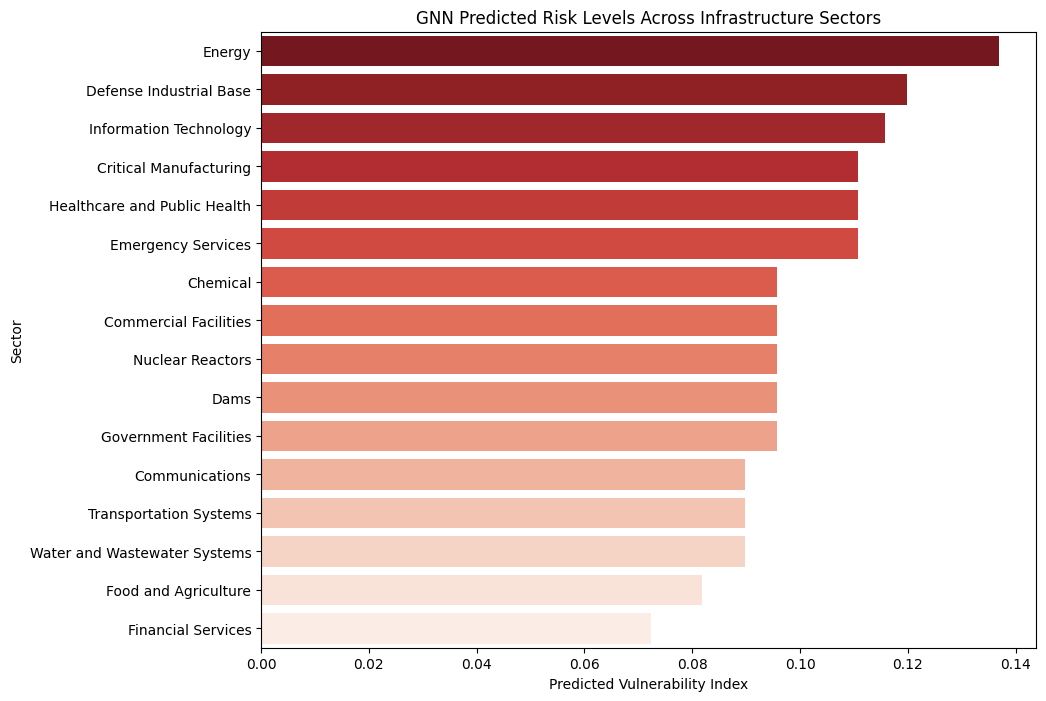

,Sector,Risk Score
7,Energy,0.136938
5,Defense Industrial Base,0.119935
12,Information Technology,0.115833
3,Critical Manufacturing,0.110741
11,Healthcare and Public Health,0.110741
6,Emergency Services,0.110741
0,Chemical,0.095650
1,Commercial Facilities,0.095650
13,Nuclear Reactors,0.095650
4,Dams,0.095650


In [10]:
import seaborn as sns

# Get final predictions
model.eval()
with torch.no_grad():
    final_risk = model(data).numpy().flatten()

# Create a DataFrame for visualization
risk_df = pd.DataFrame({
    'Sector': list(G.nodes()),
    'Risk Score': final_risk
}).sort_values(by='Risk Score', ascending=False)

# Plot the results with updated Seaborn parameters to avoid warnings
plt.figure(figsize=(10, 8))
sns.barplot(x='Risk Score', y='Sector', data=risk_df, hue='Sector', palette='Reds_r', legend=False)
plt.title('GNN Predicted Risk Levels Across Infrastructure Sectors')
plt.xlabel('Predicted Vulnerability Index')
plt.show()

display(risk_df)

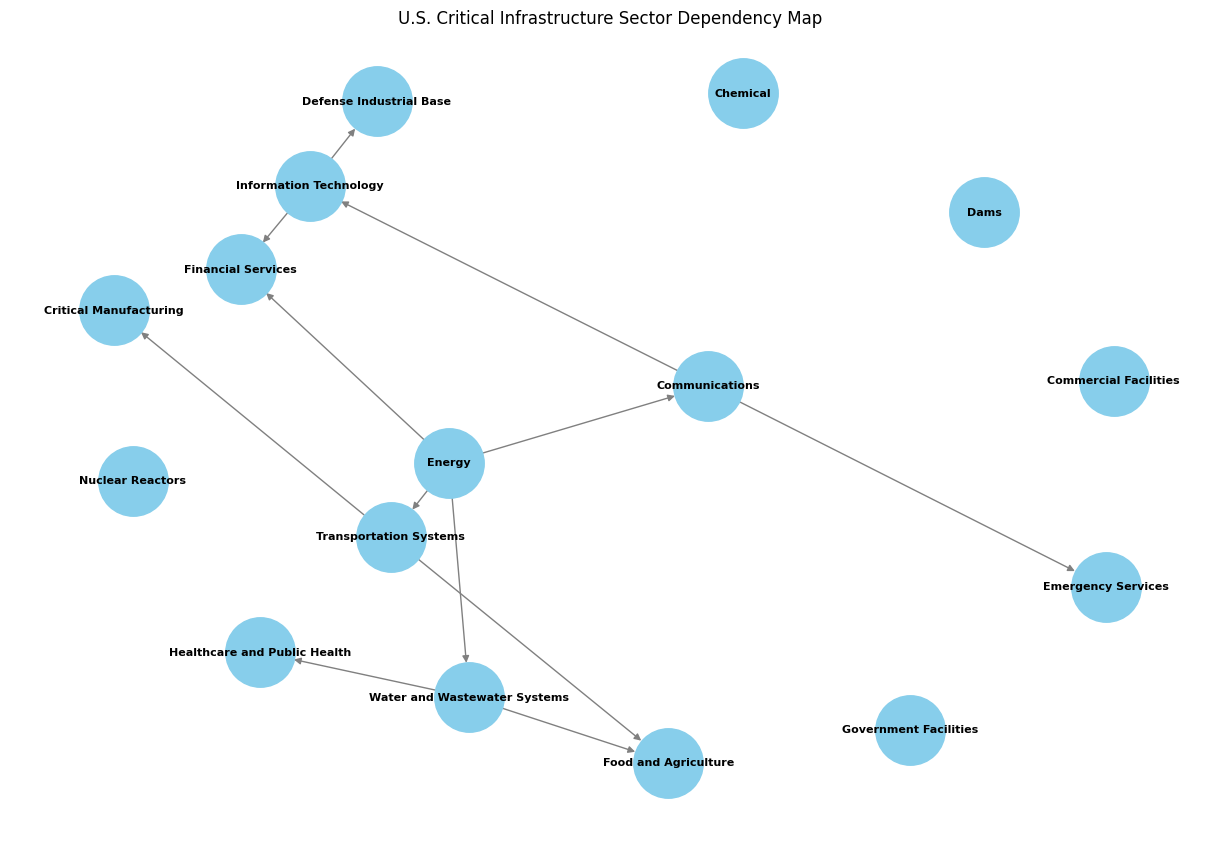

Modeled 12 key inter-sector dependencies.


In [3]:
# Define primary inter-sector dependencies
dependencies = [
    ('Energy', 'Communications'),
    ('Energy', 'Water and Wastewater Systems'),
    ('Energy', 'Transportation Systems'),
    ('Energy', 'Financial Services'),
    ('Communications', 'Information Technology'),
    ('Communications', 'Emergency Services'),
    ('Information Technology', 'Financial Services'),
    ('Information Technology', 'Defense Industrial Base'),
    ('Water and Wastewater Systems', 'Healthcare and Public Health'),
    ('Water and Wastewater Systems', 'Food and Agriculture'),
    ('Transportation Systems', 'Critical Manufacturing'),
    ('Transportation Systems', 'Food and Agriculture')
]

# Add edges to the graph
G.add_edges_from(dependencies)

# Visualize the dependency network
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='skyblue',
        node_size=2500, font_size=8, font_weight='bold',
        arrows=True, edge_color='gray')
plt.title("U.S. Critical Infrastructure Sector Dependency Map")
plt.show()

print(f"Modeled {G.number_of_edges()} key inter-sector dependencies.")

In [4]:
def simulate_cascade(graph, initial_failure_node):
    """Simulates a simple cascading failure based on dependencies."""
    failed_nodes = {initial_failure_node}
    active_nodes = set(graph.nodes()) - failed_nodes

    print(f"--- Cascade Simulation: Failure at {initial_failure_node} ---")

    # Logic: If a dependency fails, there is a chance the downstream sector fails
    new_failures = True
    while new_failures:
        new_failures = False
        for node in list(active_nodes):
            # Check if any predecessors (suppliers) have failed
            predecessors = list(graph.predecessors(node))
            if predecessors and any(p in failed_nodes for p in predecessors):
                # Simulating a high probability of failure (80%)
                if np.random.rand() < 0.8:
                    print(f"Sector Failure: {node} impacted by upstream disruption.")
                    failed_nodes.add(node)
                    active_nodes.remove(node)
                    new_failures = True

    return failed_nodes

# Example simulation
results = simulate_cascade(G, 'Energy')

--- Cascade Simulation: Failure at Energy ---
Sector Failure: Financial Services impacted by upstream disruption.
Sector Failure: Water and Wastewater Systems impacted by upstream disruption.
Sector Failure: Communications impacted by upstream disruption.
Sector Failure: Food and Agriculture impacted by upstream disruption.
Sector Failure: Information Technology impacted by upstream disruption.
Sector Failure: Healthcare and Public Health impacted by upstream disruption.
Sector Failure: Transportation Systems impacted by upstream disruption.
Sector Failure: Defense Industrial Base impacted by upstream disruption.
Sector Failure: Emergency Services impacted by upstream disruption.
Sector Failure: Critical Manufacturing impacted by upstream disruption.


## Resilience Analysis and Risk Prediction
Using Graph Neural Networks to evaluate infrastructure stability and predict sector-specific risk levels.